# Text Classification Using BoW và TF-IDF
Notebook này xây dựng một pipeline phân loại cảm xúc đa ngôn ngữ với 3 nhãn: `negative`, `neutral`, `positive`.

Luồng xử lý chính gồm: cài đặt thư viện, tải dataset, lấy sample, encode nhãn, tiền xử lý văn bản, chia train/test, benchmark BoW và TF-IDF với nhiều mô hình, chọn cấu hình TF-IDF tốt hơn, huấn luyện Logistic Regression, đánh giá tổng thể, đánh giá theo từng ngôn ngữ và lưu kết quả để phân tích lỗi.

In [ ]:
# 1. Cài đặt và import thư viện
% pip install datasets scikit-learn pandas numpy matplotlib seaborn -q
import re
import time
import warnings
import unicodedata
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
print("===Thư viện đã sẵn sàng!===")

d:\Training_Assignments\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


===Thư viện đã sẵn sàng!===


### 2. Load dataset

**Đã làm gì:**  
Cell này tải dataset `clapAI/MultiLingualSentiment` từ Hugging Face và chuyển dữ liệu sang pandas `DataFrame`.

**Code hoạt động như thế nào:**  
`load_dataset(..., split="train")` lấy tập train của dataset. Sau đó `.to_pandas()` chuyển dataset sang DataFrame để dễ thao tác. Các lệnh `print` hiển thị kích thước dữ liệu, danh sách cột, phân bố nhãn và top các ngôn ngữ xuất hiện nhiều nhất.

In [2]:
# 2. Load dataset
print("Đang tải dataset clapAI/MultiLingualSentiment train split...")
dataset = load_dataset("clapAI/MultiLingualSentiment", split="train")
df = dataset.to_pandas()
print(f"Dataset shape: {df.shape}")
print("\nCác cột:", df.columns.tolist())
print("\nPhân bố nhãn:")
print(df["label"].value_counts())
print("\nTop 15 ngôn ngữ:")
print(df["language"].value_counts().head(15))

Đang tải dataset clapAI/MultiLingualSentiment train split...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/314M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/98.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3147478 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/393435 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/393436 [00:00<?, ? examples/s]

Dataset shape: (3147478, 5)

Các cột: ['text', 'label', 'source', 'domain', 'language']

Phân bố nhãn:
label
positive    1165038
negative    1149231
neutral      833209
Name: count, dtype: int64

Top 15 ngôn ngữ:
language
en              1215709
zh               356172
ja               268241
fr               210298
ko               207998
es               178434
de               170216
ar               166677
ru               164148
vi               101655
pt                39313
tr                35794
id                10007
hi                 7514
multilingual       7513
Name: count, dtype: int64


### 3.Random sample
**Đã làm gì:**  
Cell này lấy tối đa 700,000 mẫu từ dataset gốc để tạo tập dữ liệu làm việc.

**Code hoạt động như thế nào:**  
`min(700000, len(df))` đảm bảo số mẫu không vượt quá số dòng thật của dataset. `df.sample(..., random_state=42)` lấy mẫu ngẫu nhiên nhưng có thể tái lập kết quả. `reset_index(drop=True)` đặt lại index sau khi lấy mẫu. Cuối cell, code kiểm tra lại phân bố label và top ngôn ngữ trong subset.

**Tại sao lại làm vậy:**  
Dataset gốc có thể rất lớn, train toàn bộ sẽ tốn nhiều thời gian và tài nguyên. Lấy sample giúp notebook chạy thực tế hơn nhưng vẫn giữ đủ dữ liệu để huấn luyện và đánh giá mô hình có ý nghĩa.

In [3]:
# 3. chọn ngẫu nhiên sample
sample_size = min(700000, len(df))
df_sample = df.sample(
    n=sample_size,
    random_state=42
).reset_index(drop=True)
print(f"Đã lấy subset: {len(df_sample):,} mẫu")
print("\nPhân bố label trong subset:")
print(df_sample["label"].value_counts(normalize=True).round(4))
print("\nTop 15 ngôn ngữ trong subset:")
print(df_sample["language"].value_counts().head(15))

Đã lấy subset: 700,000 mẫu

Phân bố label trong subset:
label
positive    0.3706
negative    0.3650
neutral     0.2644
Name: proportion, dtype: float64

Top 15 ngôn ngữ trong subset:
language
en              270107
zh               79370
ja               60003
fr               46638
ko               46194
es               39602
de               37900
ar               37200
ru               36539
vi               22548
pt                8594
tr                7882
id                2242
hi                1698
multilingual      1644
Name: count, dtype: int64


### 4.Encode label
**Đã làm gì:**  
Cell này chuyển nhãn cảm xúc dạng chữ sang nhãn dạng số.

**Code hoạt động như thế nào:**  
`label_map` ánh xạ `negative`, `neutral`, `positive` thành `0`, `1`, `2`. `id2label` là ánh xạ ngược từ số về tên nhãn để đọc kết quả dễ hơn. Cột mới `label_num` được tạo bằng `.map(label_map)`. Cell cũng kiểm tra xem có nhãn nào không map được hay không.

**Tại sao lại làm vậy:**  
Các mô hình machine learning trong scikit-learn thường làm việc với nhãn dạng số. Việc giữ cả `label_map` và `id2label` giúp quá trình train thuận tiện, đồng thời khi báo cáo kết quả vẫn hiển thị được tên nhãn dễ hiểu.

In [4]:
# 4. Encode label
label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}
id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}
df_sample["label_num"] = df_sample["label"].map(label_map)
# Kiểm tra label lỗi
missing_labels = df_sample["label_num"].isna().sum()
print(f"Số label không map được: {missing_labels}")
print("\nMapping label:")
print(label_map)

Số label không map được: 0

Mapping label:
{'negative': 0, 'neutral': 1, 'positive': 2}


### 5. Tiền xử lý văn bản đa ngôn ngữ

**Đã làm gì:**  
Cell này tạo hàm làm sạch văn bản ở mức nhẹ và áp dụng cho toàn bộ dữ liệu sample.

**Code hoạt động như thế nào:**  
Hàm `clean_text_minimal` kiểm tra nếu input không phải chuỗi thì trả về chuỗi rỗng. Sau đó hàm chuẩn hóa Unicode bằng `unicodedata.normalize("NFC", text)`, chuyển chữ thường, thay URL bằng token `URL`, email bằng `EMAIL`, số bằng `NUM`, rồi chuẩn hóa khoảng trắng. `.apply()` được dùng để tạo cột `clean_text`. Cuối cell, notebook in một số ví dụ trước và sau tiền xử lý theo từng ngôn ngữ.

**Tại sao lại làm vậy:**  
Dữ liệu đa ngôn ngữ không nên bị làm sạch quá mạnh bằng các regex chỉ giữ `a-z`, vì như vậy sẽ làm mất dấu tiếng Việt và phá hỏng nhiều ngôn ngữ như Pháp, Đức, Trung, Nhật, Hàn. Tiền xử lý nhẹ giúp giảm nhiễu phổ biến nhưng vẫn giữ lại thông tin quan trọng phục vụ phân loại cảm xúc.

In [5]:
# 5. Tiền xử lý cho multilingual sentiment
def clean_text_minimal(text):
    if not isinstance(text, str):
        return ""

    # Giữ Unicode ở dạng chuẩn, không bỏ dấu
    text = unicodedata.normalize("NFC", text)
    # Lowercase để giảm vocabulary
    text = text.lower()
    # Chuẩn hóa một số pattern phổ biến
    text = re.sub(r"http\S+|www\S+", " URL ", text)
    text = re.sub(r"\S+@\S+", " EMAIL ", text)
    text = re.sub(r"\d+", " NUM ", text)
    # K dùng regex kiểu [^a-z] vì sẽ phá tiếng Việt, Pháp, Đức, Tây Ban Nha...
    # K xóa punctuation mạnh tay vì char n-gram đôi khi vẫn tận dụng được ngữ cảnh.
    # Chỉ chuẩn hóa khoảng trắng.
    text = re.sub(r"\s+", " ", text).strip()
    return text
    
start_pre = time.time()
df_sample["clean_text"] = df_sample["text"].apply(clean_text_minimal)
end_pre = time.time()
print(f"Hoàn thành tiền xử lý trong {end_pre - start_pre:.2f} giây")
print("\n=== Ví dụ sau tiền xử lý ===")
languages_to_check = ["en", "vi", "zh", "ja", "ko", "ar", "fr", "es", "de"]
for lang in languages_to_check:
    if lang in df_sample["language"].values:
        sample = df_sample[df_sample["language"] == lang].iloc[0]
        original = sample["text"]
        cleaned = sample["clean_text"]
        print("\n" + "=" * 80)
        print(f"Language: {lang}")
        print("Original:", original[:250] + "..." if len(original) > 250 else original)
        print("Cleaned :", cleaned[:250] + "..." if len(cleaned) > 250 else cleaned)

Hoàn thành tiền xử lý trong 32.51 giây

=== Ví dụ sau tiền xử lý ===

Language: en
Original: I don't know what's up with this app these days, but it's always so slow to load photos, it's very frustrating and annoying! It happens suddenly, like one instance it would be loading fine, then the next, it would refuse to load photos for some minut...
Cleaned : i don't know what's up with this app these days, but it's always so slow to load photos, it's very frustrating and annoying! it happens suddenly, like one instance it would be loading fine, then the next, it would refuse to load photos for some minut...

Language: vi
Original: Tối ưu hóa phần cứng phần mềm chưa tốt chậm lag kinh khủng tệ gây ức chế cho mẹ tôi
Cleaned : tối ưu hóa phần cứng phần mềm chưa tốt chậm lag kinh khủng tệ gây ức chế cho mẹ tôi

Language: zh
Original: 酒店设施一般，但是前台和客服，行李生都很尽责，而且还给客人免费升级房间
Cleaned : 酒店设施一般，但是前台和客服，行李生都很尽责，而且还给客人免费升级房间

Language: ja
Original: 下がる
使っているうちに徐々に下がってきます。滑り止めがついていればいいのですが。
Cleaned : 下がる 使

### 6. Chia train/test theo language và label

**Đã làm gì:**  
Cell này chia dữ liệu thành tập train và test, đồng thời cố gắng giữ phân bố ngôn ngữ và nhãn tương đối ổn định ở cả hai tập.

**Code hoạt động như thế nào:**  
Cột `strata` được tạo bằng cách ghép `language` và `label`. Các nhóm `strata` có ít hơn 2 mẫu bị loại vì `train_test_split` không thể stratify các nhóm quá nhỏ. Sau đó `train_test_split` chia dữ liệu theo tỷ lệ 80% train và 20% test, với `stratify=df_sample["strata"]` để giữ phân bố theo cả ngôn ngữ và nhãn.

**Tại sao lại làm vậy:**  
Nếu chỉ stratify theo label, một số ngôn ngữ có thể bị lệch giữa train và test. Với bài toán sentiment đa ngôn ngữ, cần đánh giá công bằng hơn bằng cách giữ tương đối ổn định cả phân bố ngôn ngữ lẫn phân bố nhãn.

In [6]:
# 6. Chia train/test theo cả language + label
# Stratify theo language_label giúp train/test giữ phân bố ngôn ngữ và nhãn ổn định hơn.
df_sample["strata"] = (
    df_sample["language"].astype(str)
    + "_"
    + df_sample["label"].astype(str)
)
# train_test_split yêu cầu mỗi strata có ít nhất 2 mẫu
strata_counts = df_sample["strata"].value_counts()
valid_strata = strata_counts[strata_counts >= 2].index
before_filter = len(df_sample)
df_sample = df_sample[df_sample["strata"].isin(valid_strata)].reset_index(drop=True)
after_filter = len(df_sample)
print(f"Số mẫu trước khi lọc strata hiếm: {before_filter:,}")
print(f"Số mẫu sau khi lọc strata hiếm : {after_filter:,}")
X = df_sample["clean_text"]
y = df_sample["label_num"]
languages = df_sample["language"]
X_train, X_test, y_train, y_test, lang_train, lang_test = train_test_split(
    X,
    y,
    languages,
    test_size=0.2,
    random_state=42,
    stratify=df_sample["strata"]
)
print(f"Train samples: {len(X_train):,}")
print(f"Test samples : {len(X_test):,}")
print("\nPhân bố label trong train:")
print(y_train.map(id2label).value_counts(normalize=True).round(4))
print("\nPhân bố label trong test:")
print(y_test.map(id2label).value_counts(normalize=True).round(4))

Số mẫu trước khi lọc strata hiếm: 700,000
Số mẫu sau khi lọc strata hiếm : 700,000
Train samples: 560,000
Test samples : 140,000

Phân bố label trong train:
label_num
positive    0.3706
negative    0.3650
neutral     0.2644
Name: proportion, dtype: float64

Phân bố label trong test:
label_num
positive    0.3706
negative    0.3650
neutral     0.2644
Name: proportion, dtype: float64


### 6A. Benchmark BoW, TF-IDF, Logistic Regression và Naive Bayes

**Đã làm gì:**  
Cell này huấn luyện và so sánh 4 cấu hình mô hình: BoW + Logistic Regression, BoW + Naive Bayes, TF-IDF + Logistic Regression, TF-IDF + Naive Bayes.

**Code hoạt động như thế nào:**  
Hàm `evaluate_benchmark_model` nhận một pipeline, train bằng `.fit()`, dự đoán bằng `.predict()`, sau đó tính `accuracy`, `f1_macro`, `f1_weighted`, thời gian train và thời gian predict. `CountVectorizer` tạo đặc trưng Bag of Words. `TfidfVectorizer` tạo đặc trưng TF-IDF ở mức word n-gram và char n-gram, sau đó `FeatureUnion` nối hai nhóm đặc trưng lại. Kết quả benchmark được lưu vào `benchmark_results_df` và xuất ra file CSV.

**Tại sao lại làm vậy:**  
Benchmark giúp xác định cách biểu diễn văn bản và thuật toán nào phù hợp hơn với dữ liệu. BoW đơn giản, dễ hiểu và thường nhanh; TF-IDF thường hiệu quả hơn vì giảm trọng số của từ quá phổ biến. Char n-gram đặc biệt hữu ích cho dữ liệu đa ngôn ngữ vì giúp mô hình học được mẫu ký tự, lỗi chính tả và các ngôn ngữ không tách từ bằng khoảng trắng rõ ràng.


In [ ]:
# 6A. Benchmark: BoW / TF-IDF + Logistic Regression / Naive Bayes
# - Dùng cùng X_train, X_test, y_train, y_test đã tạo ở bước split.
# - BoW dùng CountVectorizer.
# - TF-IDF dùng FeatureUnion word TF-IDF + char TF-IDF để phù hợp dữ liệu đa ngôn ngữ.
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.base import clone
benchmark_results = []
benchmark_predictions = {}
def evaluate_benchmark_model(model_name, pipeline, X_train, y_train, X_test, y_test):
    print("=" * 100)
    print(f"Đang huấn luyện: {model_name}")
    print("=" * 100)
    start_fit = time.time()
    pipeline.fit(X_train, y_train)
    fit_time = time.time() - start_fit
    start_pred = time.time()
    y_pred_bench = pipeline.predict(X_test)
    pred_time = time.time() - start_pred
    acc = accuracy_score(y_test, y_pred_bench)
    f1_macro = f1_score(y_test, y_pred_bench, average="macro")
    f1_weighted = f1_score(y_test, y_pred_bench, average="weighted")

    benchmark_results.append({
        "model": model_name,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "train_time_sec": fit_time,
        "predict_time_sec": pred_time,
        "total_time_sec": fit_time + pred_time
    })
    benchmark_predictions[model_name] = y_pred_bench
    print(f"Accuracy        : {acc:.4f}")
    print(f"F1 macro        : {f1_macro:.4f}")
    print(f"F1 weighted     : {f1_weighted:.4f}")
    print(f"Training time   : {fit_time:.2f} giây")
    print(f"Prediction time : {pred_time:.2f} giây")
    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred_bench,
            target_names=["negative", "neutral", "positive"],
            digits=4
        )
    )
    return pipeline
 
# 1. Cấu hình BoW
 
# BoW không dùng sublinear_tf vì đây là CountVectorizer.
# min_df=3 giúp giảm nhiễu khi sample lớn.
# max_features nên thấp hơn TF-IDF một chút để chạy nhanh hơn.
bow_vectorizer = CountVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    max_features=250_000,
    min_df=3,
    max_df=0.90,
    lowercase=False,
    dtype=np.int32
)
 
# 2. Cấu hình TF-IDF cho benchmark
 
# Dùng word 1-2 gram + char 2-6 gram.
# Char n-gram giúp tốt hơn với Chinese/Japanese/Korean và tiếng có dấu.
benchmark_word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    max_features=250_000,
    min_df=3,
    max_df=0.90,
    sublinear_tf=True,
    lowercase=False,
    norm="l2",
    dtype=np.float32
)
benchmark_char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(2, 6),
    max_features=350_000,
    min_df=3,
    max_df=0.90,
    sublinear_tf=True,
    lowercase=False,
    norm="l2",
    dtype=np.float32
)
benchmark_tfidf_features = FeatureUnion([
    ("word_tfidf", benchmark_word_tfidf),
    ("char_tfidf", benchmark_char_tfidf)
])
 
# 3. Tạo 4 pipeline benchmark
 
benchmark_pipelines = {
    "BoW + Logistic Regression": Pipeline([
        ("vectorizer", clone(bow_vectorizer)),
        ("clf", LogisticRegression(
            max_iter=2_000,
            C=2.0,
            class_weight="balanced",
            solver="saga",
            n_jobs=-1,
            random_state=42
        ))
    ]),

    "BoW + Naive Bayes": Pipeline([
        ("vectorizer", clone(bow_vectorizer)),
        ("clf", MultinomialNB(
            alpha=0.5
        ))
    ]),

    "TF-IDF + Logistic Regression": Pipeline([
        ("features", clone(benchmark_tfidf_features)),
        ("clf", LogisticRegression(
            max_iter=2_000,
            C=2.0,
            class_weight="balanced",
            solver="saga",
            n_jobs=-1,
            random_state=42
        ))
    ]),

    "TF-IDF + Naive Bayes": Pipeline([
        ("features", clone(benchmark_tfidf_features)),
        ("clf", MultinomialNB(
            alpha=0.5
        ))
    ])
}
# 4. Huấn luyện và đánh giá
trained_benchmark_models = {}

for name, pipe in benchmark_pipelines.items():
    trained_benchmark_models[name] = evaluate_benchmark_model(
        model_name=name,
        pipeline=pipe,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test
    )

# 5. Bảng so sánh tổng hợp
benchmark_results_df = pd.DataFrame(benchmark_results)
benchmark_results_df = benchmark_results_df.sort_values(
    by=["f1_macro", "accuracy"],
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 100)
print("BẢNG SO SÁNH 4 MÔ HÌNH")
print("=" * 100)
display(benchmark_results_df.round(4))

# Lưu kết quả benchmark
benchmark_results_df.to_csv("bow_tfidf_model_comparison.csv", index=False)
print("\n Đã lưu bảng so sánh vào: bow_tfidf_model_comparison.csv")


Đang huấn luyện: BoW + Logistic Regression
Accuracy        : 0.6793
F1 macro        : 0.6779
F1 weighted     : 0.6870
Training time   : 3017.80 giây
Prediction time : 10.59 giây

Classification Report:
              precision    recall  f1-score   support

    negative     0.7793    0.6607    0.7151     51097
     neutral     0.4990    0.7211    0.5898     37013
    positive     0.8021    0.6677    0.7287     51890

    accuracy                         0.6793    140000
   macro avg     0.6935    0.6832    0.6779    140000
weighted avg     0.7136    0.6793    0.6870    140000

Đang huấn luyện: BoW + Naive Bayes
Accuracy        : 0.6175
F1 macro        : 0.6117
F1 weighted     : 0.6177
Training time   : 86.28 giây
Prediction time : 10.92 giây

Classification Report:
              precision    recall  f1-score   support

    negative     0.7303    0.5343    0.6171     51097
     neutral     0.5145    0.6031    0.5553     37013
    positive     0.6216    0.7096    0.6627     51890

    acc

,model,accuracy,f1_macro,f1_weighted,train_time_sec,predict_time_sec,total_time_sec
0,TF-IDF + Logistic Regression,0.7471,0.7383,0.7485,24981.5016,90.8919,25072.3935
1,BoW + Logistic Regression,0.6792,0.6779,0.6870,3017.7957,10.5943,3028.3900
2,TF-IDF + Naive Bayes,0.6705,0.6638,0.6733,502.9375,92.9217,595.8592
3,BoW + Naive Bayes,0.6175,0.6117,0.6177,86.2843,10.9216,97.2059



✅ Đã lưu bảng so sánh vào: bow_tfidf_model_comparison.csv


### 6B. Trực quan hóa kết quả benchmark


Cell này vẽ biểu đồ so sánh các mô hình theo Accuracy, F1 macro và thời gian huấn luyện.

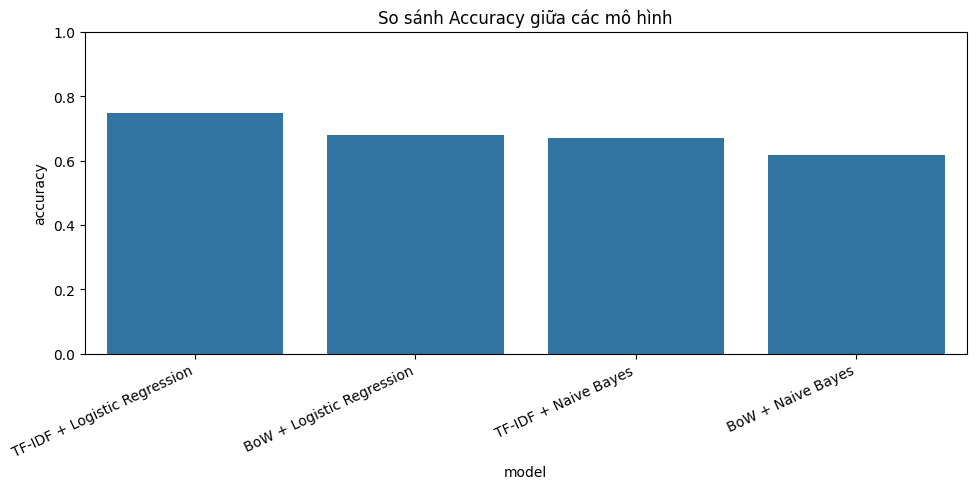

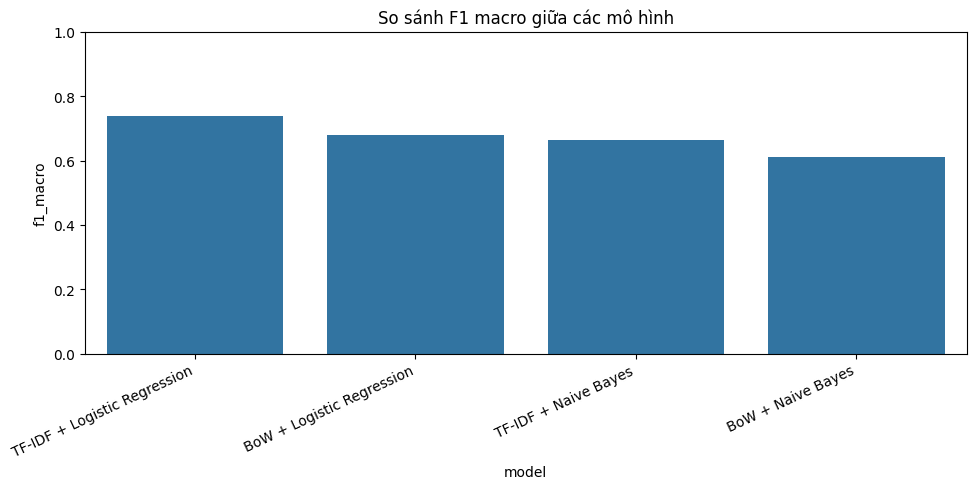

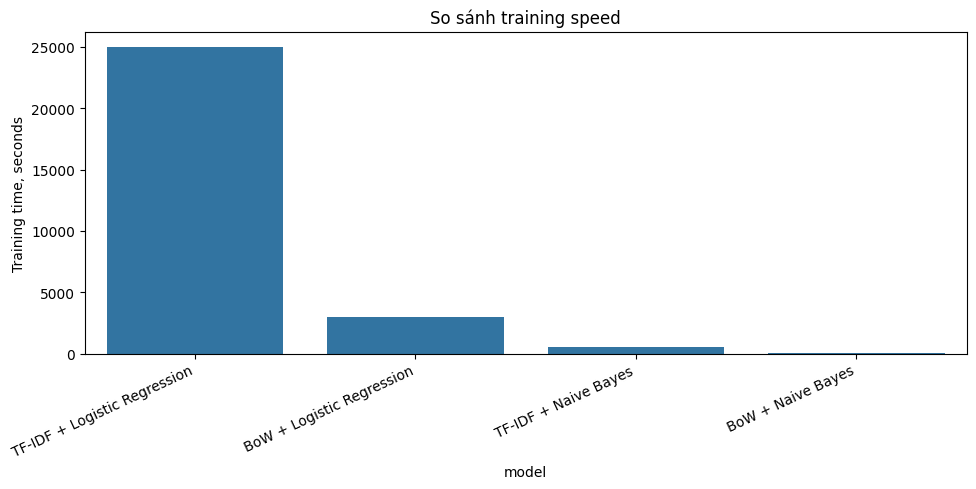

In [8]:
# 6B. Trực quan hóa so sánh Accuracy, F1 và tốc độ train

if "benchmark_results_df" in globals() and len(benchmark_results_df) > 0:
    plot_df = benchmark_results_df.copy()

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=plot_df,
        x="model",
        y="accuracy"
    )
    plt.title("So sánh Accuracy giữa các mô hình")
    plt.xticks(rotation=25, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=plot_df,
        x="model",
        y="f1_macro"
    )
    plt.title("So sánh F1 macro giữa các mô hình")
    plt.xticks(rotation=25, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=plot_df,
        x="model",
        y="train_time_sec"
    )
    plt.title("So sánh training speed")
    plt.ylabel("Training time, seconds")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Chưa có benchmark_results_df. Hãy chạy cell benchmark trước.")


### 7. Cấu hình vector hóa TF-IDF word và char

**Đã làm gì:**  
Cell này cấu hình bộ trích xuất đặc trưng chính cho mô hình cuối: word TF-IDF kết hợp với char TF-IDF.

**Code hoạt động như thế nào:**  
`word_tfidf` lấy word n-gram từ 1 đến 2 từ. `char_tfidf` lấy char n-gram trong biên từ từ 3 đến 5 ký tự. Các tham số `max_features`, `min_df`, `max_df` giới hạn số đặc trưng và loại bớt token quá hiếm hoặc quá phổ biến. `FeatureUnion` nối đặc trưng word-level và char-level thành một ma trận đặc trưng chung.

**Tại sao lại làm vậy:**  
Word n-gram giúp bắt các từ và cụm từ mang sắc thái cảm xúc, còn char n-gram giúp mô hình xử lý tốt hơn tiếng có dấu, lỗi chính tả, biến thể từ và các ngôn ngữ như Trung, Nhật, Hàn. Kết hợp cả hai thường ổn định hơn so với chỉ dùng một loại đặc trưng.


In [9]:
# 7. Vectorization: word 1-2 gram + char 3-5 gram TF-IDF
# Vì dataset đa ngôn ngữ, word-level TF-IDF không đủ tốt cho Chinese/Japanese/Korean.
# Kết hợp word n-gram và char n-gram giúp model học cả cụm từ sentiment và mảnh ký tự đa ngôn ngữ.
word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    max_features=200_000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    lowercase=False
)
char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=200_000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    lowercase=False
)
features = FeatureUnion([
    ("word_tfidf", word_tfidf),
    ("char_tfidf", char_tfidf)
])
print("Đã cấu hình FeatureUnion gồm word TF-IDF + char TF-IDF")

Đã cấu hình FeatureUnion gồm word TF-IDF + char TF-IDF


### 8. Huấn luyện Logistic Regression

**Đã làm gì:**  
Cell này tạo pipeline mô hình cuối và huấn luyện Logistic Regression trên đặc trưng TF-IDF.

**Code hoạt động như thế nào:**  
Pipeline gồm hai bước: `features` để vector hóa text và `clf` để phân loại. `LogisticRegression` dùng `solver="saga"` phù hợp với ma trận sparse lớn từ TF-IDF, `class_weight="balanced"` tự điều chỉnh trọng số lớp, `C=5.0` kiểm soát mức regularization, và `n_jobs=-1` tận dụng nhiều CPU. Cell cũng đo thời gian huấn luyện bằng `time.time()`.

**Tại sao lại làm vậy:**  
Logistic Regression là baseline mạnh cho phân loại văn bản với đặc trưng sparse như TF-IDF. `class_weight="balanced"` giúp giảm tình trạng mô hình thiên về lớp có nhiều mẫu hơn, đặc biệt hữu ích khi các nhãn sentiment không cân bằng.


In [10]:
# 8. Logistic Regression với class_weight='balanced'
# class_weight='balanced' giúp giảm tình trạng model bỏ qua lớp khó hơn như neutral.
# solver='saga' phù hợp với sparse matrix lớn từ TF-IDF.
model = Pipeline([
    ("features", features),
    ("clf", LogisticRegression(
        max_iter=2_000,
        C=5.0,
        class_weight="balanced",
        solver="saga",
        n_jobs=-1,
        random_state=42,
        verbose=0
    ))
])
print("Đang huấn luyện Logistic Regression + Word/Char TF-IDF...")
start_train = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Huấn luyện xong trong {train_time:.2f} giây")

Đang huấn luyện Logistic Regression + Word/Char TF-IDF...
Huấn luyện xong trong 714.45 giây


### 9. Đánh giá tổng thể mô hình

**Đã làm gì:**  
Cell này đánh giá mô hình cuối trên tập test.

**Code hoạt động như thế nào:**  
`model.predict(X_test)` tạo dự đoán cho tập test. Sau đó code tính `accuracy`, `f1_macro`, `f1_weighted`, in `classification_report`, tạo `confusion_matrix` và vẽ heatmap bằng seaborn.

**Tại sao lại làm vậy:**  
Accuracy cho biết tỷ lệ dự đoán đúng tổng thể, còn F1 macro quan trọng khi các lớp không cân bằng vì mỗi lớp được tính ngang nhau. `classification_report` cho biết precision, recall và F1 theo từng nhãn. Confusion matrix giúp nhận diện mô hình thường nhầm giữa cặp nhãn nào, ví dụ `neutral` bị nhầm thành `positive` hay `negative`.


KẾT QUẢ TỔNG THỂ
Accuracy    : 0.7289
F1 macro    : 0.7200
F1 weighted : 0.7305

Classification Report:
              precision    recall  f1-score   support

    negative     0.7702    0.7544    0.7622     51097
     neutral     0.5960    0.6440    0.6191     37013
    positive     0.7939    0.7643    0.7788     51890

    accuracy                         0.7289    140000
   macro avg     0.7200    0.7209    0.7200    140000
weighted avg     0.7329    0.7289    0.7305    140000


Confusion Matrix:
               pred_negative  pred_neutral  pred_positive
true_negative          38548          8352           4197
true_neutral            7081         23836           6096
true_positive           4423          7807          39660


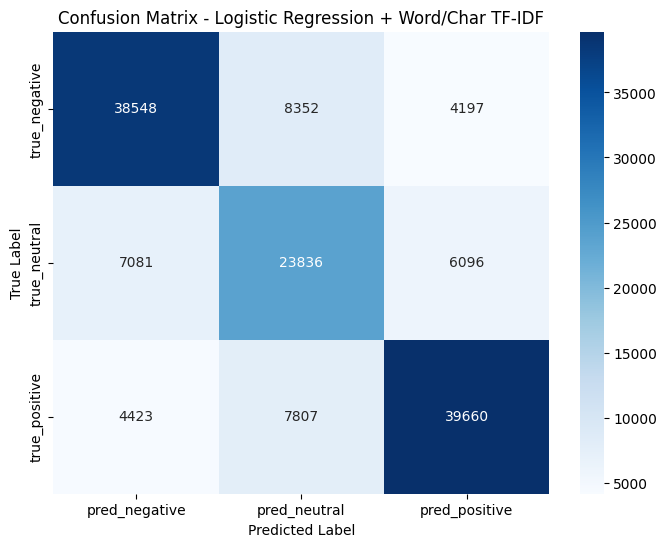

In [11]:
# 9. Đánh giá tổng thể
y_pred = model.predict(X_test)
overall_acc = accuracy_score(y_test, y_pred)
overall_f1_macro = f1_score(y_test, y_pred, average="macro")
overall_f1_weighted = f1_score(y_test, y_pred, average="weighted")
print("=" * 80)
print("KẾT QUẢ TỔNG THỂ")
print("=" * 80)
print(f"Accuracy    : {overall_acc:.4f}")
print(f"F1 macro    : {overall_f1_macro:.4f}")
print(f"F1 weighted : {overall_f1_weighted:.4f}")
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["negative", "neutral", "positive"],
        digits=4
    )
)
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["true_negative", "true_neutral", "true_positive"],
    columns=["pred_negative", "pred_neutral", "pred_positive"]
)
print("\nConfusion Matrix:")
print(cm_df)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix - Logistic Regression + Word/Char TF-IDF")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

### 10. Đánh giá theo từng ngôn ngữ

**Đã làm gì:**  
Cell này tính chất lượng mô hình riêng cho từng ngôn ngữ trong tập test.

**Code hoạt động như thế nào:**  
`eval_df` gom text, language, nhãn thật và nhãn dự đoán vào một DataFrame. Vòng lặp đi qua từng ngôn ngữ, bỏ qua ngôn ngữ có dưới 20 mẫu test vì metric dễ nhiễu, sau đó tính accuracy, F1 macro và F1 weighted. Kết quả được sắp xếp theo F1 macro và in ra nhóm ngôn ngữ tốt nhất, yếu nhất.

**Tại sao lại làm vậy:**  
Với dữ liệu đa ngôn ngữ, điểm tổng thể có thể che giấu việc model hoạt động tốt ở ngôn ngữ nhiều dữ liệu nhưng yếu ở ngôn ngữ ít dữ liệu. Đánh giá theo language giúp phát hiện nhóm ngôn ngữ cần cải thiện thêm về dữ liệu, tiền xử lý hoặc đặc trưng.


In [12]:
# 10. Đánh giá riêng theo từng language
eval_df = pd.DataFrame({
    "text": X_test.values,
    "language": lang_test.values,
    "y_true": y_test.values,
    "y_pred": y_pred
})
language_results = []
for lang in sorted(eval_df["language"].dropna().unique()):
    sub = eval_df[eval_df["language"] == lang]
    # Bỏ qua ngôn ngữ có quá ít mẫu trong test vì metric dễ nhiễu
    if len(sub) < 20:
        continue
    language_results.append({
        "language": lang,
        "n_samples": len(sub),
        "accuracy": accuracy_score(sub["y_true"], sub["y_pred"]),
        "f1_macro": f1_score(sub["y_true"], sub["y_pred"], average="macro"),
        "f1_weighted": f1_score(sub["y_true"], sub["y_pred"], average="weighted")
    })
language_results_df = pd.DataFrame(language_results)
language_results_df = language_results_df.sort_values("f1_macro", ascending=False)
print("=" * 80)
print("KẾT QUẢ THEO TỪNG NGÔN NGỮ")
print("=" * 80)
print(language_results_df.round(4))
print("\n10 ngôn ngữ yếu nhất theo F1 macro:")
print(language_results_df.sort_values("f1_macro").head(10).round(4))
print("\n10 ngôn ngữ tốt nhất theo F1 macro:")
print(language_results_df.sort_values("f1_macro", ascending=False).head(10).round(4))

KẾT QUẢ THEO TỪNG NGÔN NGỮ
        language  n_samples  accuracy  f1_macro  f1_weighted
13            ru       7307    0.8386    0.7834       0.8401
2             en      54021    0.7503    0.7479       0.7505
9             ko       9239    0.7032    0.7015       0.7026
8             ja      12001    0.7099    0.6900       0.7130
4             fr       9328    0.7605    0.6862       0.7585
1             de       7580    0.7322    0.6851       0.7324
15            vi       4510    0.8503    0.6815       0.8475
0             ar       7439    0.6819    0.6796       0.6815
6             id        449    0.7840    0.6759       0.7760
12            pt       1719    0.6713    0.6752       0.6724
3             es       7921    0.7200    0.6712       0.7201
16            zh      15874    0.6157    0.6140       0.6221
10            ms        249    0.5944    0.5709       0.5939
14            tr       1576    0.8084    0.5326       0.8238
7             it        119    0.5126    0.5079       0.50

### 11. Báo cáo chi tiết cho các ngôn ngữ yếu nhất

**Đã làm gì:**  
Cell này in classification report cho 5 ngôn ngữ có F1 macro thấp nhất.

**Code hoạt động như thế nào:**  
Code lấy danh sách `worst_languages` bằng cách sort `language_results_df` tăng dần theo `f1_macro`. Với mỗi ngôn ngữ, code lọc các dòng tương ứng trong `eval_df` và in `classification_report` theo ba nhãn sentiment.

**Tại sao lại làm vậy:**  
Biết ngôn ngữ nào yếu là chưa đủ; cần xem trong từng ngôn ngữ đó mô hình yếu ở lớp nào. Báo cáo chi tiết giúp xác định model đang nhầm nhiều ở `neutral`, `negative` hay `positive`, từ đó định hướng cải thiện dữ liệu hoặc mô hình.


In [13]:
# 11. Classification report chi tiết cho các ngôn ngữ yếu nhất
if len(language_results_df) > 0:
    worst_languages = language_results_df.sort_values("f1_macro").head(5)["language"].tolist()
    for lang in worst_languages:
        sub = eval_df[eval_df["language"] == lang]
        print("\n" + "=" * 80)
        print(f"Language: {lang}")
        print(f"Number of test samples: {len(sub)}")
        print(
            classification_report(
                sub["y_true"],
                sub["y_pred"],
                target_names=["negative", "neutral", "positive"],
                digits=4
            )
        )
else:
    print("Không đủ dữ liệu để đánh giá theo language.")


Language: multilingual
Number of test samples: 329
              precision    recall  f1-score   support

    negative     0.2000    0.4643    0.2796        28
     neutral     0.2542    0.2174    0.2344        69
    positive     0.7707    0.6810    0.7231       232

    accuracy                         0.5653       329
   macro avg     0.4083    0.4542    0.4124       329
weighted avg     0.6138    0.5653    0.5829       329


Language: hi
Number of test samples: 339
              precision    recall  f1-score   support

    negative     0.3671    0.2929    0.3258        99
     neutral     0.5495    0.6410    0.5917       156
    positive     0.4231    0.3929    0.4074        84

    accuracy                         0.4779       339
   macro avg     0.4465    0.4423    0.4417       339
weighted avg     0.4649    0.4779    0.4684       339


Language: it
Number of test samples: 119
              precision    recall  f1-score   support

    negative     0.5111    0.5750    0.5412    

### 12. Lưu kết quả và phân tích lỗi

**Đã làm gì:**  
Cell này tạo bảng phân tích dự đoán đúng/sai và lưu kết quả ra file CSV.

**Code hoạt động như thế nào:**  
Code map `y_true` và `y_pred` từ số về tên nhãn, tạo cột `is_correct`, lọc các dòng sai thành `error_df`, hiển thị 20 lỗi đầu tiên, rồi lưu `eval_df` vào `tfidf_multilingual_predictions.csv` và `language_results_df` vào `tfidf_language_results.csv`.

**Tại sao lại làm vậy:**  
Lưu kết quả giúp phân tích lỗi sau khi notebook chạy xong mà không cần train lại mô hình. Xem các mẫu dự đoán sai là bước quan trọng để hiểu hạn chế của model và quyết định cải thiện tiền xử lý, dữ liệu, đặc trưng hoặc thuật toán.


In [14]:
# 12. Lưu kết quả dự đoán để phân tích lỗi
eval_df["y_true_label"] = eval_df["y_true"].map(id2label)
eval_df["y_pred_label"] = eval_df["y_pred"].map(id2label)
eval_df["is_correct"] = eval_df["y_true"] == eval_df["y_pred"]
error_df = eval_df[~eval_df["is_correct"]].copy()
print(f"Tổng số mẫu test: {len(eval_df):,}")
print(f"Số mẫu dự đoán sai: {len(error_df):,}")
print("\nMột số lỗi mẫu:")
display(error_df.head(20))
# Có thể lưu ra CSV nếu chạy trên Colab/Jupyter
eval_df.to_csv("tfidf_multilingual_predictions.csv", index=False)
language_results_df.to_csv("tfidf_language_results.csv", index=False)
print("\n Đã lưu:")
print("- tfidf_multilingual_predictions.csv")
print("- tfidf_language_results.csv")

Tổng số mẫu test: 140,000
Số mẫu dự đoán sai: 37,956

Một số lỗi mẫu:


,text,language,y_true,y_pred,y_true_label,y_pred_label,is_correct
2,no absorve bien el polvo. no es de las mejores...,es,0,1,negative,neutral,False
4,한편의 다큐를 보는듯한 느낌임.매우리얼함.강추,ko,2,1,positive,neutral,False
10,good course when you want to get to know some ...,en,2,0,positive,negative,False
11,đó là giáo trình và tài liệu .,vi,1,0,neutral,negative,False
13,"letra pequeña. sigo opinando lo mismo, y es qu...",es,1,0,neutral,negative,False
15,锦州[开学季][开学季][开学季],zh,0,1,negative,neutral,False
20,価格的にも・・・ 満足のいく商品でした。 急な故障でしたので、すぐに商品が到着したのが大変助...,ja,2,1,positive,neutral,False
24,里面的音标和现在我们课本学的不一样，不是美式也不是英式,zh,1,0,neutral,negative,False
25,الرواية تتحدث عن العبث والعدم في مواجهة الايما...,ar,1,0,neutral,negative,False
31,food here is amazing! my friend and i came on ...,en,1,2,neutral,positive,False



 Đã lưu:
- tfidf_multilingual_predictions.csv
- tfidf_language_results.csv
